# Fase 4 — Interacciones 2-way entre VI de tarea

**Objetivo:** Determinar si los **efectos base** documentados en la Fase 3 se mantienen de forma **aditiva** o dependen de la **combinación** con otra variable independiente de tarea (interacción). Este análisis guiará la especificación de términos de interacción en los GLMM de fases posteriores.

**Dataset:** `Matriz_V3.xlsx` (4 446 observaciones × 19 variables).

| VD normalizada | Etiqueta corta |
|---|---|
| `Total Touches / min` | Toques / min |
| `Golpeos +15 m/s / min` | Golpeos / min |
| `Distance Covered (m) / min` | Distancia / min |
| `High Intensity Distance (20 km/h) / min` | HID / min |

| VI de tarea | Niveles |
|---|---|
| `Espacio` | amplio / reducido |
| `Agrupacion` | grande / pequeno |
| `Polaridad` | polarizado / no polarizado |
| `Equilibrio` | equilibrio / desequilibrio |

### Pares de VI analizados (C(4,2) = 6)

1. Espacio × Agrupación
2. Espacio × Polaridad
3. Espacio × Equilibrio
4. Agrupación × Polaridad
5. Agrupación × Equilibrio
6. Polaridad × Equilibrio

**Combinaciones totales:** 6 pares × 4 VD = **24 análisis de interacción**.

> **Nota:** No se incluye `GrupoEdad` como factor en este notebook. Las interacciones con GrupoEdad se abordarán en los modelos GLMM.

In [1]:
# ── Librerías ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings

# statsmodels para ANOVA factorial y regresión logística
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

from IPython.display import display, Markdown

# ── Configuración global ──────────────────────────────────
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 12,
    "axes.labelpad": 8,
    "grid.alpha": 0.30,
    "grid.linewidth": 0.5,
    "grid.color": "#CCCCCC",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
})
%matplotlib inline

# ── Carga del dataset ─────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

# ── Variables dependientes normalizadas ───────────────────
vd_cols = [
    "Total Touches / min",
    "Golpeos +15 m/s / min",
    "Distance Covered (m) / min",
    "High Intensity Distance (20 km/h) / min",
]

vd_labels = [
    "Toques / min",
    "Golpeos / min",
    "Distancia / min",
    "HID / min",
]

vd_to_label = dict(zip(vd_cols, vd_labels))
label_to_vd = dict(zip(vd_labels, vd_cols))

# ── Variables independientes de tarea ─────────────────────
vi_cols = ["Espacio", "Agrupacion", "Polaridad", "Equilibrio"]

# Niveles ordenados de cada VI
vi_niveles = {vi: sorted(df[vi].dropna().unique().tolist()) for vi in vi_cols}

# ── Generación de los 6 pares de VI ──────────────────────
pares_vi = list(combinations(vi_cols, 2))
print(f"\n✔ {len(pares_vi)} pares de VI generados:")
for i, (v1, v2) in enumerate(pares_vi, 1):
    print(f"   {i}. {v1} × {v2}")

# ── VD con inflación de ceros ─────────────────────────────
vd_zeros = ["Golpeos +15 m/s / min", "High Intensity Distance (20 km/h) / min"]
vd_zeros_labels = ["Golpeos / min", "HID / min"]

# ── Paletas de colores ────────────────────────────────────
colores_vd = sns.color_palette("Set2", n_colors=len(vd_cols))
vd_to_color = dict(zip(vd_cols, colores_vd))
PAL_NIVEL = ["#5A9BD5", "#F28E2B"]   # Azul acero · Naranja cálido
PAL_INTER = ["#2C7BB6", "#D7191C"]   # Azul oscuro · Rojo — para líneas de interacción

# ── Verificación ──────────────────────────────────────────
for col in vd_cols + vi_cols:
    assert col in df.columns, f"Columna '{col}' no encontrada."
print(f"\n✔ {len(vd_cols)} VD y {len(vi_cols)} VI verificadas.")
print(f"✔ {len(pares_vi)} pares × {len(vd_cols)} VD = {len(pares_vi) * len(vd_cols)} combinaciones de interacción.")

Dimensiones: 4446 filas × 19 columnas

✔ 6 pares de VI generados:
   1. Espacio × Agrupacion
   2. Espacio × Polaridad
   3. Espacio × Equilibrio
   4. Agrupacion × Polaridad
   5. Agrupacion × Equilibrio
   6. Polaridad × Equilibrio

✔ 4 VD y 4 VI verificadas.
✔ 6 pares × 4 VD = 24 combinaciones de interacción.


---
## Sección 1 — Tablas de medias cruzadas 2×2

Para cada par de VI × cada VD se calcula la **media**, **SD** y **N** en las 4 celdas del cruce factorial. Para **Golpeos/min** y **HID/min**, se añade además el **% de ceros** y la **media condicional (> 0)** en cada celda, extendiendo el enfoque interruptor/modulador de la Fase 3 al contexto cruzado.

In [2]:
# ── Sección 1: Tablas de medias cruzadas 2×2 ─────────────

for vi1, vi2 in pares_vi:
    display(Markdown(f"### Par: **{vi1} × {vi2}**"))
    
    filas = []
    for vd, label in zip(vd_cols, vd_labels):
        for niv1 in vi_niveles[vi1]:
            for niv2 in vi_niveles[vi2]:
                sub = df[(df[vi1] == niv1) & (df[vi2] == niv2)][vd].dropna()
                fila = {
                    "VD": label,
                    vi1: niv1,
                    vi2: niv2,
                    "N": len(sub),
                    "Media": round(sub.mean(), 4) if len(sub) > 0 else np.nan,
                    "SD": round(sub.std(ddof=1), 4) if len(sub) > 1 else np.nan,
                }
                # Añadir info de ceros para Golpeos y HID
                if vd in vd_zeros:
                    n_ceros = int((sub == 0).sum()) if len(sub) > 0 else 0
                    pct_ceros = round((sub == 0).mean() * 100, 1) if len(sub) > 0 else np.nan
                    sub_pos = sub[sub > 0]
                    media_cond = round(sub_pos.mean(), 4) if len(sub_pos) > 0 else np.nan
                    fila["% ceros"] = pct_ceros
                    fila["Media cond. (>0)"] = media_cond
                filas.append(fila)
    
    df_tabla = pd.DataFrame(filas)
    display(df_tabla.style.set_caption(f"Medias cruzadas: {vi1} × {vi2}").format(precision=4))
    print()

### Par: **Espacio × Agrupacion**

,VD,Espacio,Agrupacion,N,Media,SD,% ceros,Media cond. (>0)
0,Toques / min,amplio,grande,1662,1.6861,0.9252,nan,nan
1,Toques / min,amplio,pequeno,490,2.3098,2.1944,nan,nan
2,Toques / min,reducido,grande,631,2.8390,1.8650,nan,nan
3,Toques / min,reducido,pequeno,1663,3.2107,1.9034,nan,nan
4,Golpeos / min,amplio,grande,1662,0.1568,0.1679,21.2000,0.1989
5,Golpeos / min,amplio,pequeno,490,0.2810,0.4056,21.2000,0.3566
6,Golpeos / min,reducido,grande,631,0.1304,0.1611,38.4000,0.2115
7,Golpeos / min,reducido,pequeno,1663,0.1478,0.2002,36.9000,0.2344
8,Distancia / min,amplio,grande,1662,91.8115,28.7066,nan,nan
9,Distancia / min,amplio,pequeno,490,63.8705,23.7726,nan,nan


### Par: **Espacio × Polaridad**

,VD,Espacio,Polaridad,N,Media,SD,% ceros,Media cond. (>0)
0,Toques / min,amplio,No_polarizado,182,3.1252,2.3478,nan,nan
1,Toques / min,amplio,Polarizado,1970,1.7083,1.1472,nan,nan
2,Toques / min,reducido,No_polarizado,787,3.7795,2.0459,nan,nan
3,Toques / min,reducido,Polarizado,1507,2.7580,1.7184,nan,nan
4,Golpeos / min,amplio,No_polarizado,182,0.2426,0.4281,36.8000,0.3839
5,Golpeos / min,amplio,Polarizado,1970,0.1797,0.2245,19.7000,0.2239
6,Golpeos / min,reducido,No_polarizado,787,0.1066,0.1831,50.3000,0.2146
7,Golpeos / min,reducido,Polarizado,1507,0.1621,0.1913,30.5000,0.2333
8,Distancia / min,amplio,No_polarizado,182,85.8040,29.8764,nan,nan
9,Distancia / min,amplio,Polarizado,1970,85.4167,30.0583,nan,nan


### Par: **Espacio × Equilibrio**

...

,VD,Agrupacion,Polaridad,N,Media,SD,% ceros,Media cond. (>0)
0,Toques / min,grande,No_polarizado,366,3.0118,1.8909,nan,nan
1,Toques / min,grande,Polarizado,1927,1.8118,1.1332,nan,nan
2,Toques / min,pequeno,No_polarizado,603,4.0480,2.1571,nan,nan
3,Toques / min,pequeno,Polarizado,1550,2.6002,1.7916,nan,nan
4,Golpeos / min,grande,No_polarizado,366,0.1020,0.1575,51.6000,0.2108
5,Golpeos / min,grande,Polarizado,1927,0.1585,0.1666,21.0000,0.2007
6,Golpeos / min,pequeno,No_polarizado,603,0.1505,0.2958,45.4000,0.2758
7,Golpeos / min,pequeno,Polarizado,1550,0.1889,0.2546,28.6000,0.2647
8,Distancia / min,grande,No_polarizado,366,85.8588,33.8041,nan,nan
9,Distancia / min,grande,Polarizado,1927,89.5054,27.7318,nan,nan


### Par: **Agrupacion × Equilibrio**

,VD,Agrupacion,Equilibrio,N,Media,SD,% ceros,Media cond. (>0)
0,Toques / min,grande,Desequilibrio,268,2.8180,1.7597,nan,nan
1,Toques / min,grande,Equilibrio,2025,1.8956,1.2560,nan,nan
2,Toques / min,pequeno,Desequilibrio,832,3.4130,2.1218,nan,nan
3,Toques / min,pequeno,Equilibrio,1321,2.7491,1.8904,nan,nan
4,Golpeos / min,grande,Desequilibrio,268,0.1472,0.2087,42.5000,0.2561
5,Golpeos / min,grande,Equilibrio,2025,0.1498,0.1601,23.7000,0.1964
6,Golpeos / min,pequeno,Desequilibrio,832,0.1616,0.2727,39.5000,0.2673
7,Golpeos / min,pequeno,Equilibrio,1321,0.1885,0.2634,29.4000,0.2672
8,Distancia / min,grande,Desequilibrio,268,82.2778,31.8869,nan,nan
9,Distancia / min,grande,Equilibrio,2025,89.8028,28.2694,nan,nan


### Par: **Polaridad × Equilibrio**

,VD,Polaridad,Equilibrio,N,Media,SD,% ceros,Media cond. (>0)
0,Toques / min,No_polarizado,Desequilibrio,645,3.6972,2.0827,nan,nan
1,Toques / min,No_polarizado,Equilibrio,324,3.5758,2.1935,nan,nan
2,Toques / min,Polarizado,Desequilibrio,455,2.6596,1.8531,nan,nan
3,Toques / min,Polarizado,Equilibrio,3022,2.0885,1.4431,nan,nan
4,Golpeos / min,No_polarizado,Desequilibrio,645,0.1361,0.2605,47.0000,0.2567
5,Golpeos / min,No_polarizado,Equilibrio,324,0.1243,0.2396,49.4000,0.2455
6,Golpeos / min,Polarizado,Desequilibrio,455,0.1892,0.2528,30.8000,0.2734
7,Golpeos / min,Polarizado,Equilibrio,3022,0.1695,0.2038,23.5000,0.2214
8,Distancia / min,No_polarizado,Desequilibrio,645,76.3313,27.1668,nan,nan
9,Distancia / min,No_polarizado,Equilibrio,324,82.9389,30.4612,nan,nan


---
## Sección 2 — Interaction plots (line plots)

Para cada par de VI (VI₁ × VI₂) y cada VD:
- **Eje X:** niveles de VI₂.
- **Líneas:** niveles de VI₁ (con colores distintos).
- **Eje Y:** media de la VD ± SE (barras de error).

Si las líneas se **cruzan o divergen** → evidencia visual de interacción. Si son **paralelas** → efectos aditivos.

Layout: 1 figura × 4 paneles (uno por VD) para cada par de VI → **6 figuras** en total.

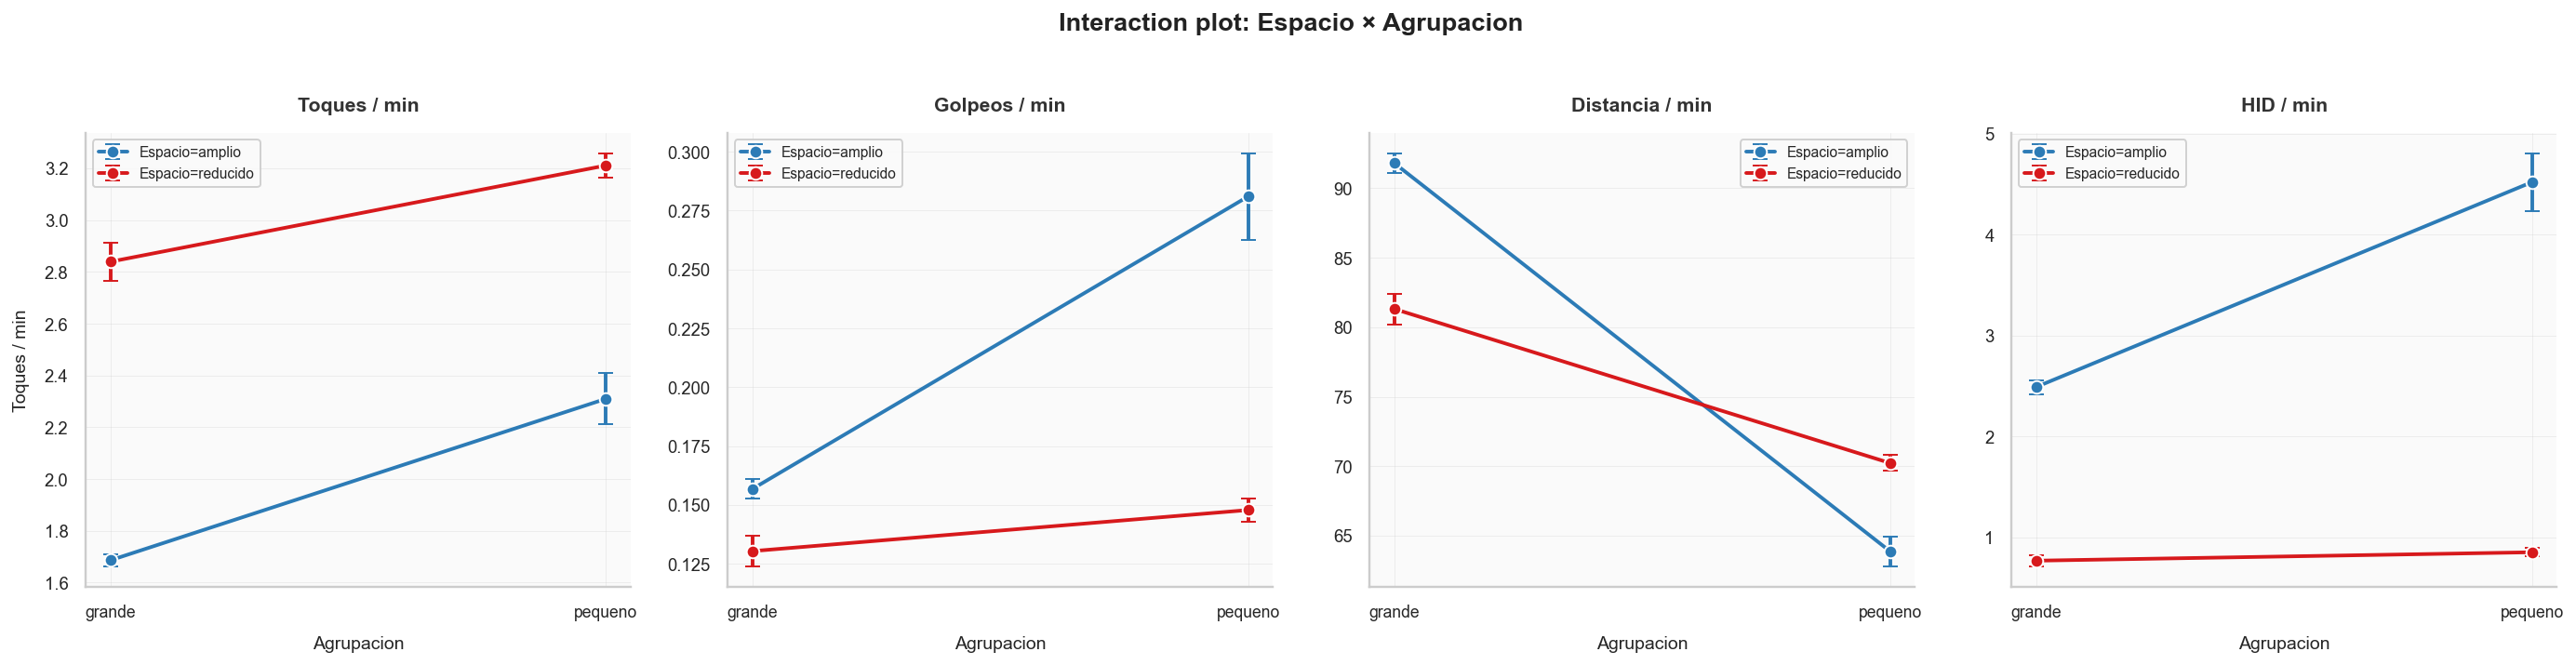

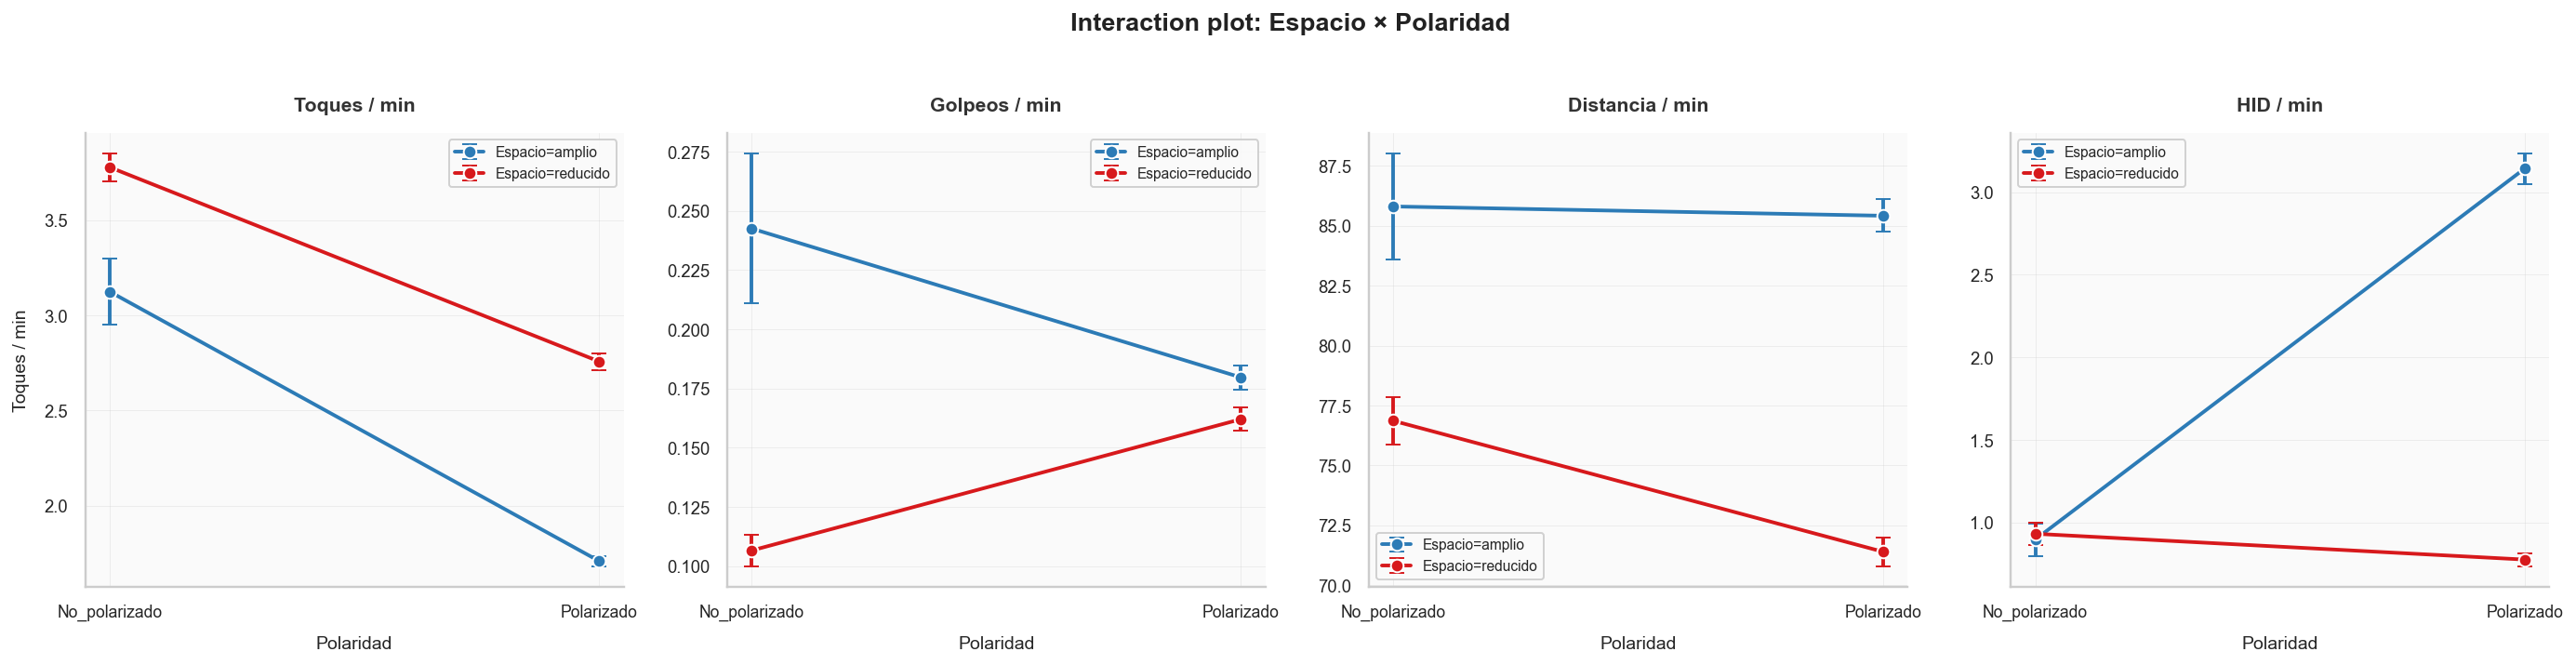

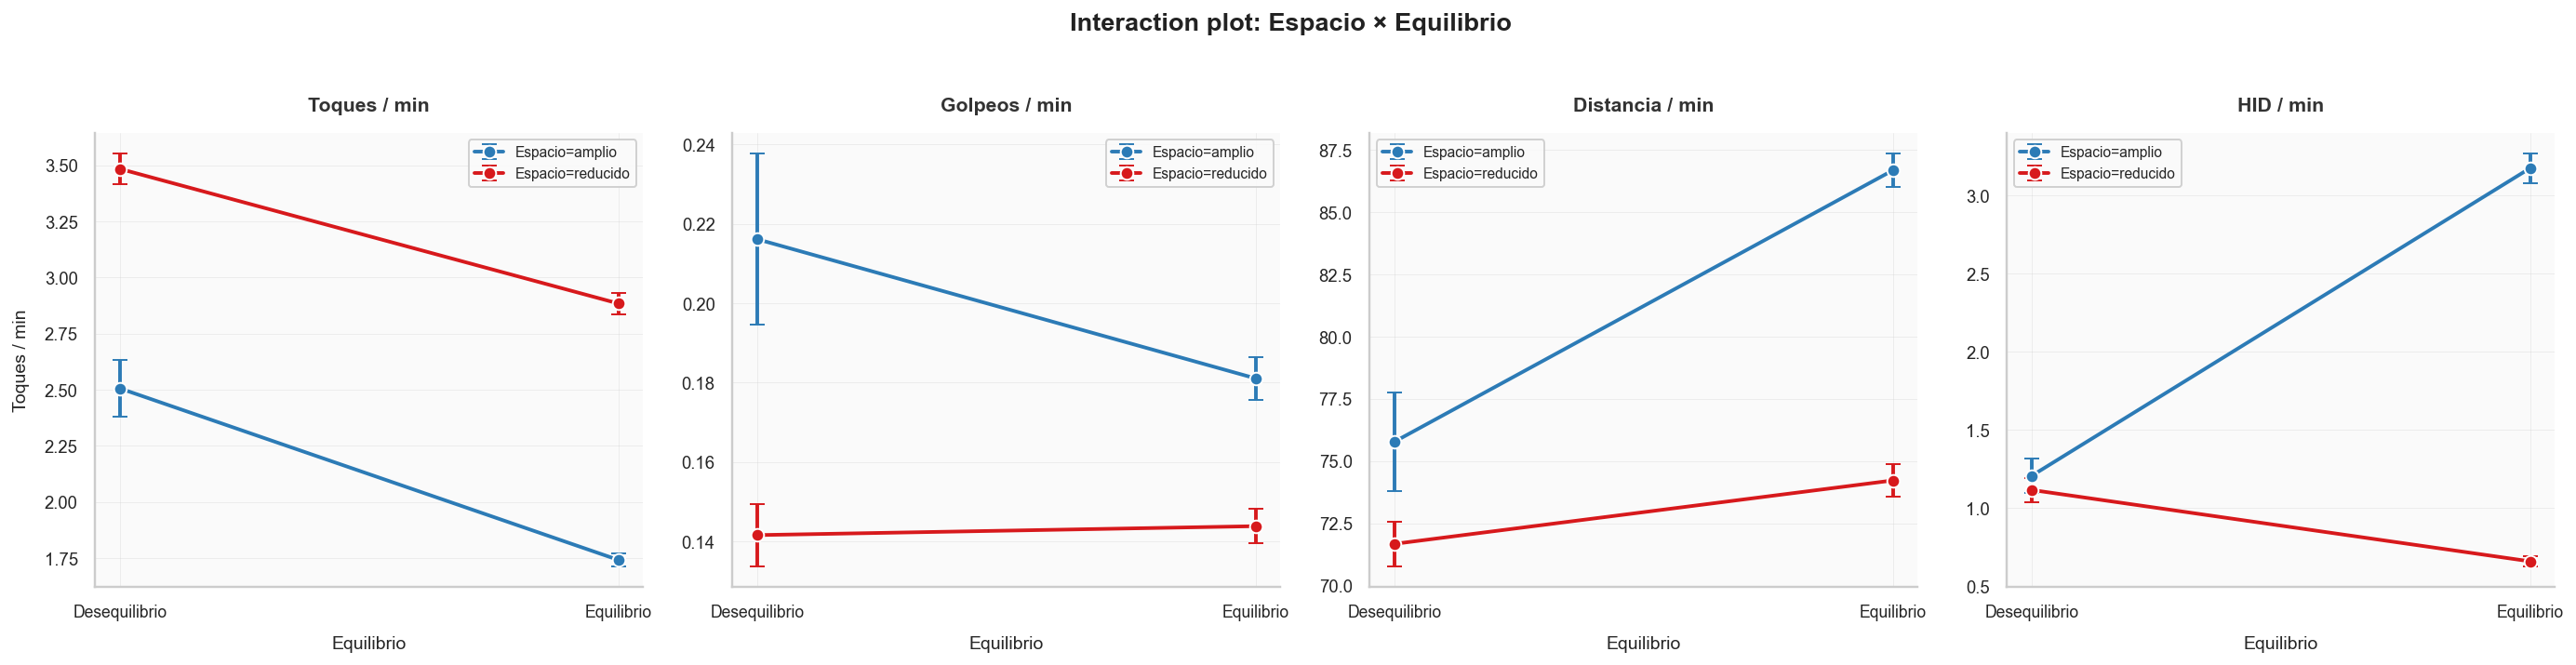

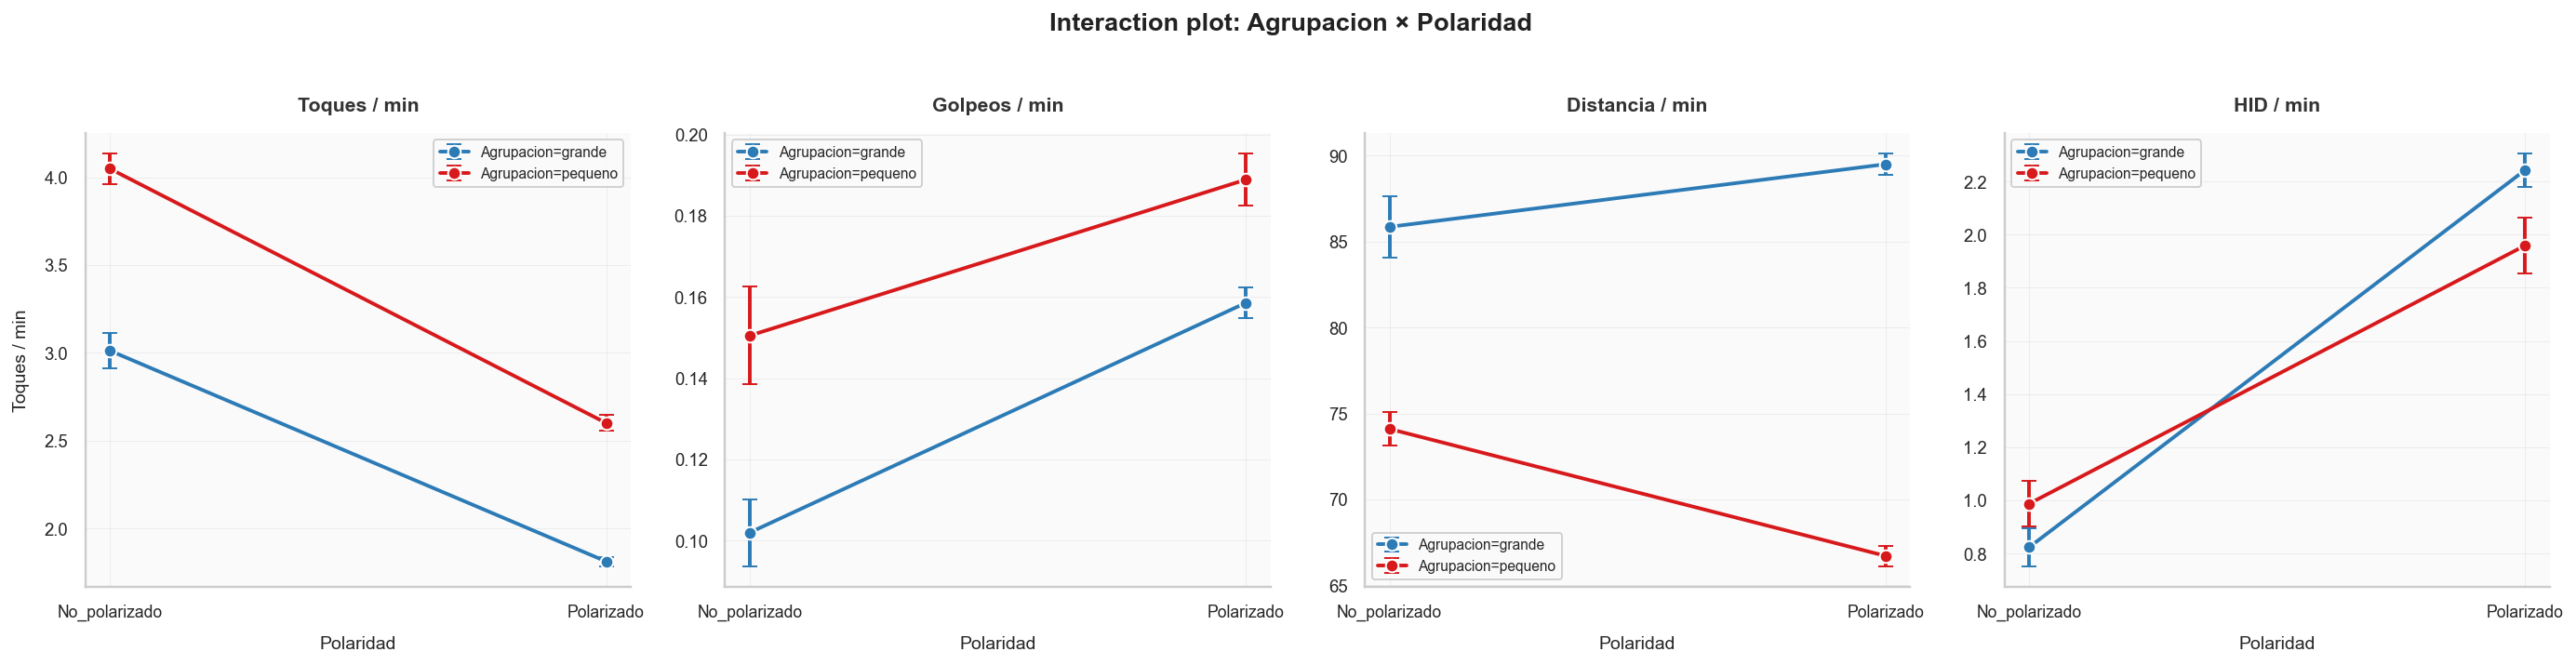

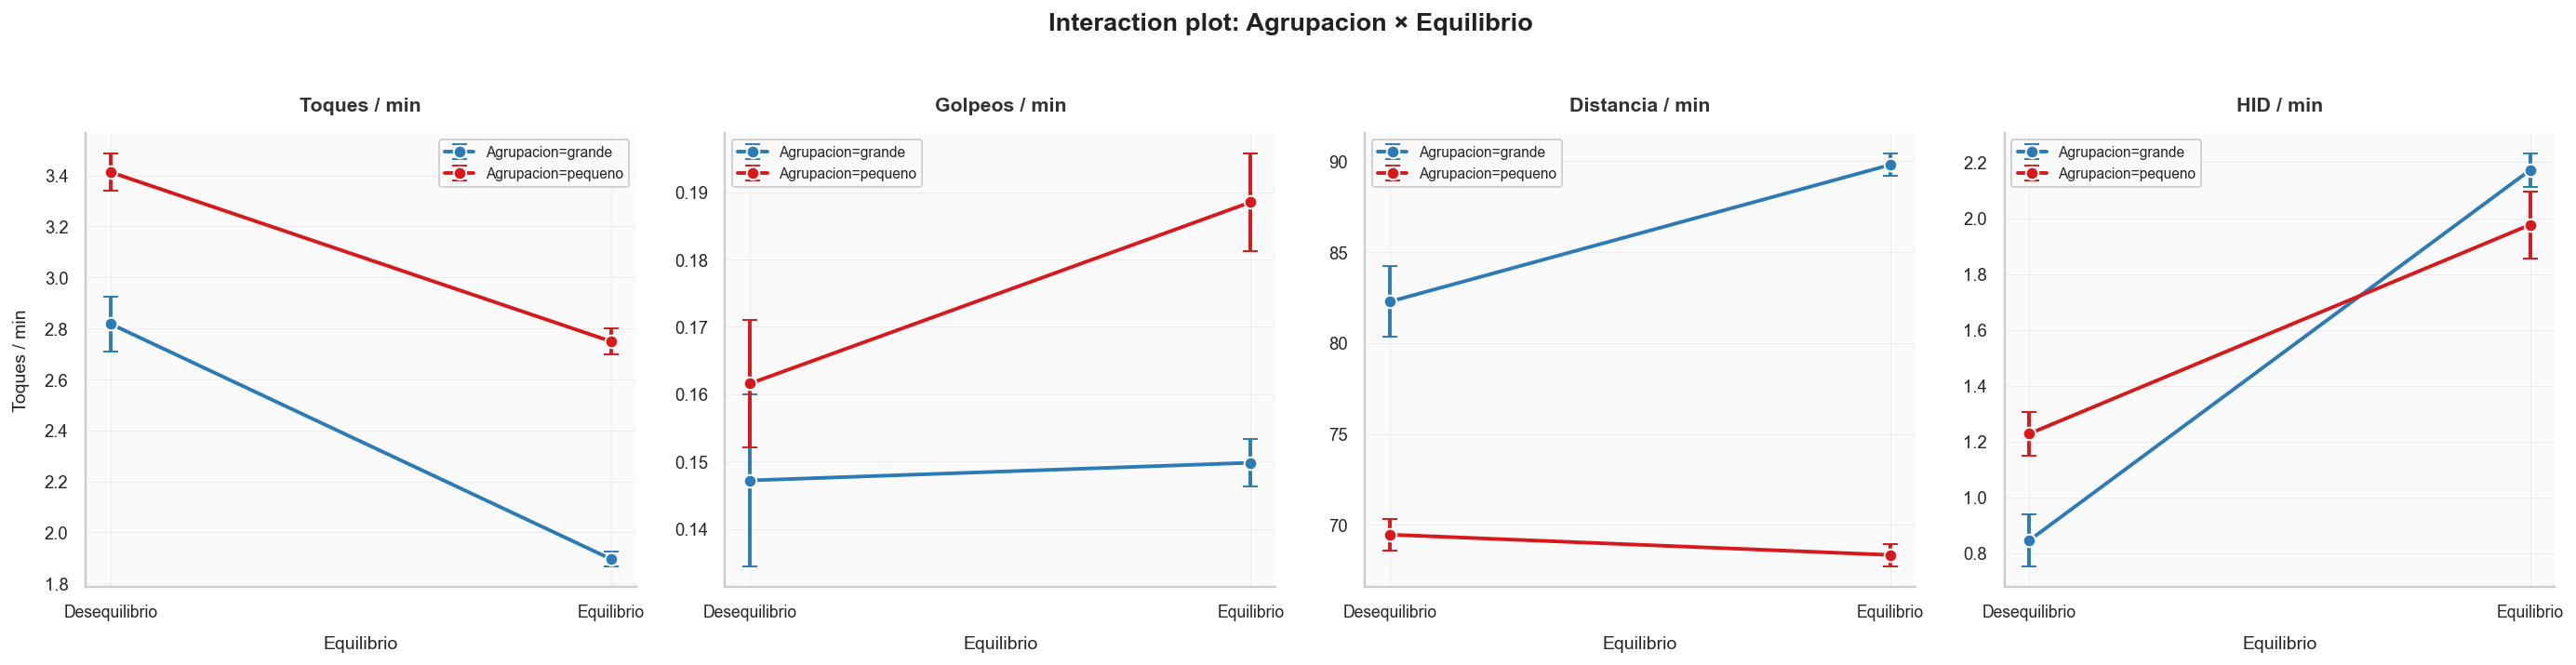

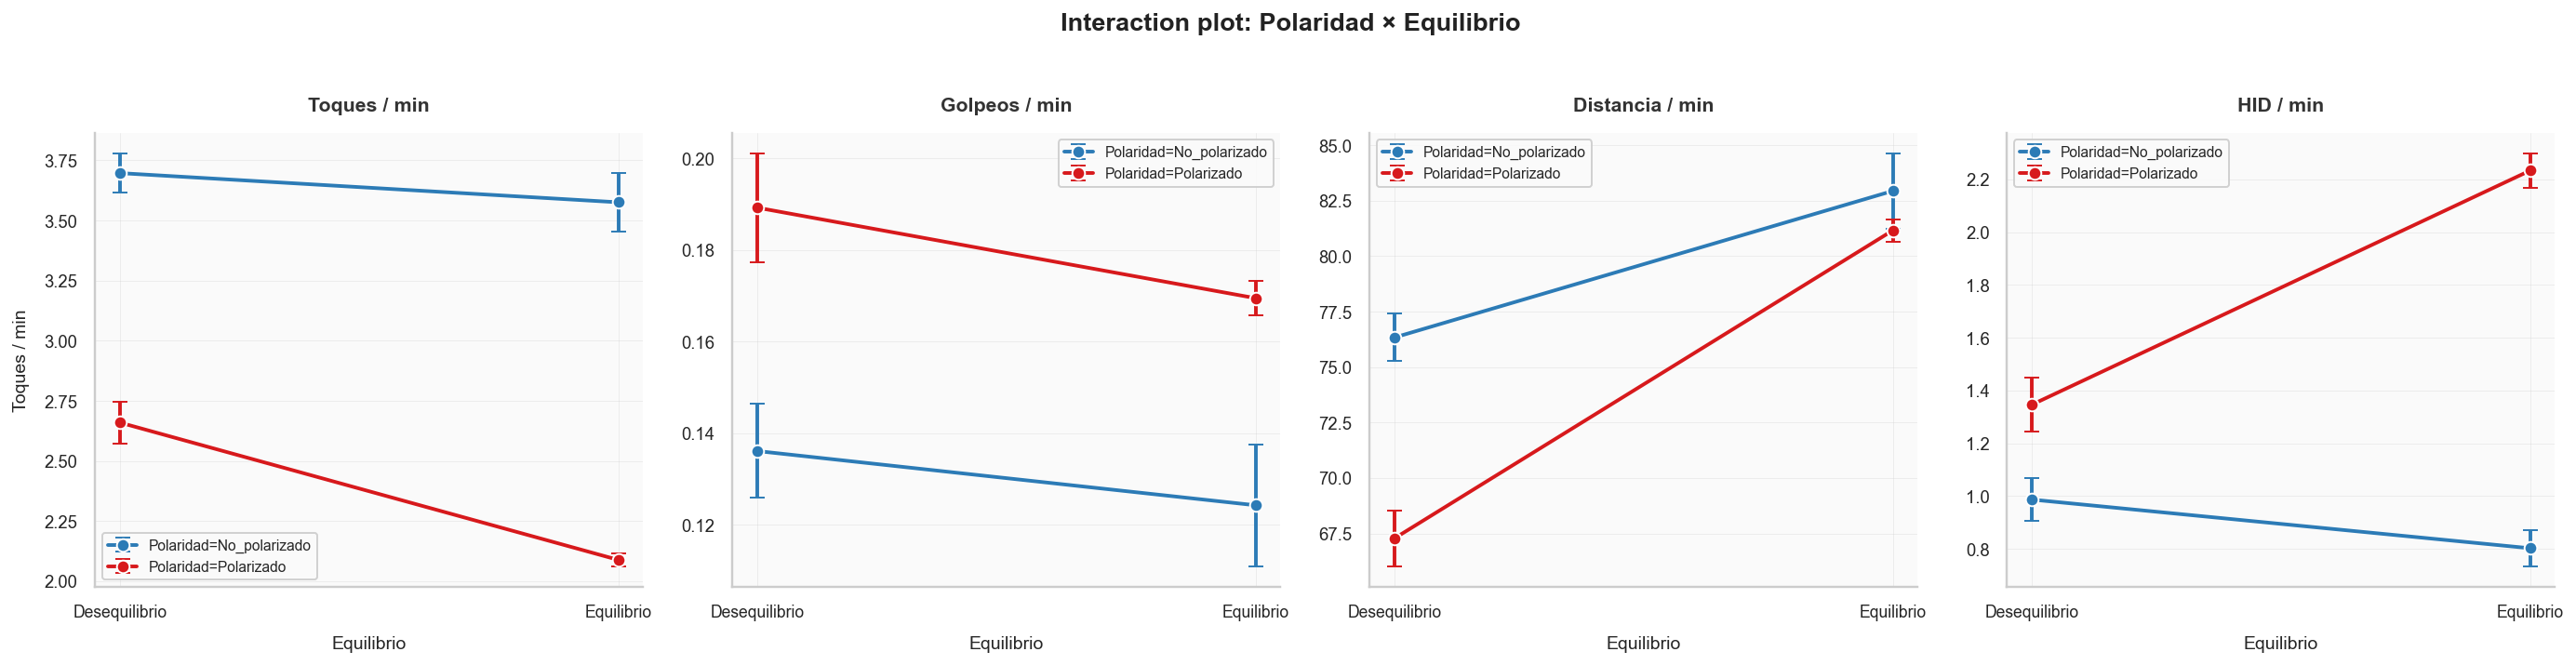

In [3]:
# ── Sección 2: Interaction plots ─────────────────────────

for vi1, vi2 in pares_vi:
    niveles_vi1 = vi_niveles[vi1]
    niveles_vi2 = vi_niveles[vi2]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for idx, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
        ax = axes[idx]
        
        for k, niv1 in enumerate(niveles_vi1):
            medias = []
            ses = []
            for niv2 in niveles_vi2:
                sub = df[(df[vi1] == niv1) & (df[vi2] == niv2)][vd].dropna()
                medias.append(sub.mean())
                se = sub.std(ddof=1) / np.sqrt(len(sub)) if len(sub) > 1 else 0
                ses.append(se)
            
            ax.errorbar(
                range(len(niveles_vi2)), medias, yerr=ses,
                marker="o", markersize=7, capsize=4, capthick=1.2,
                linewidth=2.0, color=PAL_INTER[k], label=f"{vi1}={niv1}",
                markeredgecolor="white", markeredgewidth=1.0,
            )
        
        ax.set_xticks(range(len(niveles_vi2)))
        ax.set_xticklabels(niveles_vi2, fontsize=9)
        ax.set_xlabel(vi2, fontsize=10)
        ax.set_ylabel(label if idx == 0 else "", fontsize=10)
        ax.set_title(label, fontsize=11, fontweight="bold", color="#333")
        ax.legend(fontsize=8, loc="best", framealpha=0.9)
    
    fig.suptitle(
        f"Interaction plot: {vi1} × {vi2}",
        fontsize=14, fontweight="bold", color="#222", y=1.02,
    )
    fig.tight_layout()
    plt.show()

---
## Sección 3 — ANOVA factorial 2×2 y cuantificación de la interacción

Para cada par (VI₁ × VI₂) × cada VD:

1. **ANOVA factorial 2×2** con `statsmodels` (OLS + Type II SS) para obtener:
   - F y p del efecto principal de VI₁
   - F y p del efecto principal de VI₂
   - F y p del término de interacción VI₁ × VI₂
   - η²p (eta-cuadrado parcial) de la interacción

2. **Diferencia de diferencias (ΔΔ):**
   - Δ₁ = efecto de VI₂ dentro del nivel 1 de VI₁
   - Δ₂ = efecto de VI₂ dentro del nivel 2 de VI₁
   - ΔΔ = Δ₁ − Δ₂ (= magnitud de la interacción en unidades originales)
   - ΔΔ% = ΔΔ como porcentaje de la media global de la VD

**Interpretación de η²p:** < .01 negligible · .01–.06 pequeño · .06–.14 medio · ≥ .14 grande

In [4]:
# ── Sección 3: ANOVA factorial 2×2 + Diferencia de diferencias ──

def interpretar_eta2p(eta2p):
    """Interpretación del tamaño del efecto η²p."""
    if eta2p < 0.01:
        return "Negligible"
    elif eta2p < 0.06:
        return "Pequeño"
    elif eta2p < 0.14:
        return "Medio"
    else:
        return "Grande"


def fmt_p(p):
    """Formato para p-valores: notación científica si p < .001."""
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.4f}"


filas_anova = []

for vi1, vi2 in pares_vi:
    niveles_vi1 = vi_niveles[vi1]
    niveles_vi2 = vi_niveles[vi2]
    
    for vd, label in zip(vd_cols, vd_labels):
        # ── ANOVA factorial 2×2 con statsmodels ──────────
        formula = f'Q("{vd}") ~ C({vi1}) * C({vi2})'
        modelo = smf.ols(formula, data=df).fit()
        tabla_anova = anova_lm(modelo, typ=2)
        
        # Extraer resultados del término de interacción
        inter_key = f"C({vi1}):C({vi2})"
        
        # Efectos principales
        f_vi1 = tabla_anova.loc[f"C({vi1})", "F"]
        p_vi1 = tabla_anova.loc[f"C({vi1})", "PR(>F)"]
        f_vi2 = tabla_anova.loc[f"C({vi2})", "F"]
        p_vi2 = tabla_anova.loc[f"C({vi2})", "PR(>F)"]
        
        # Interacción
        f_inter = tabla_anova.loc[inter_key, "F"]
        p_inter = tabla_anova.loc[inter_key, "PR(>F)"]
        ss_inter = tabla_anova.loc[inter_key, "sum_sq"]
        ss_resid = tabla_anova.loc["Residual", "sum_sq"]
        
        # η²p de la interacción = SS_inter / (SS_inter + SS_resid)
        eta2p_inter = ss_inter / (ss_inter + ss_resid)
        
        # ── Diferencia de diferencias (ΔΔ) ──────────────
        # Δ₁ = media(VI2=niv2_1 | VI1=niv1_0) - media(VI2=niv2_0 | VI1=niv1_0)
        m_00 = df[(df[vi1] == niveles_vi1[0]) & (df[vi2] == niveles_vi2[0])][vd].mean()
        m_01 = df[(df[vi1] == niveles_vi1[0]) & (df[vi2] == niveles_vi2[1])][vd].mean()
        m_10 = df[(df[vi1] == niveles_vi1[1]) & (df[vi2] == niveles_vi2[0])][vd].mean()
        m_11 = df[(df[vi1] == niveles_vi1[1]) & (df[vi2] == niveles_vi2[1])][vd].mean()
        
        delta_1 = m_01 - m_00  # efecto de VI₂ dentro del nivel 1 de VI₁
        delta_2 = m_11 - m_10  # efecto de VI₂ dentro del nivel 2 de VI₁
        dd = delta_1 - delta_2  # interacción en unidades originales
        
        media_global = df[vd].mean()
        dd_pct = (dd / media_global * 100) if media_global != 0 else np.nan
        
        filas_anova.append({
            "Par VI": f"{vi1} × {vi2}",
            "VD": label,
            "F(VI₁)": round(f_vi1, 2),
            "p(VI₁)": fmt_p(p_vi1),
            "F(VI₂)": round(f_vi2, 2),
            "p(VI₂)": fmt_p(p_vi2),
            "F interacción": round(f_inter, 2),
            "p interacción": p_inter,  # numérico para posterior uso
            "η²p interacción": eta2p_inter,
            "ΔΔ": round(dd, 4),
            "ΔΔ%": round(dd_pct, 2),
            "Tamaño": interpretar_eta2p(eta2p_inter),
        })

df_anova = pd.DataFrame(filas_anova)

# Crear versión de display con p formateado
df_anova_display = df_anova.copy()
df_anova_display["p interacción"] = df_anova_display["p interacción"].apply(fmt_p)
df_anova_display["η²p interacción"] = df_anova_display["η²p interacción"].apply(lambda x: f"{x:.4f}")
df_anova_display["Sig."] = df_anova["p interacción"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
)

# Estilo condicional
def _color_tamano(val):
    mapa = {"Grande": "#F8D7DA", "Medio": "#FFF3CD", "Pequeño": "#D1ECF1", "Negligible": "#D4EDDA"}
    return f"background-color: {mapa.get(val, '')}"

def _color_sig(val):
    if val in ("***", "**"):
        return "background-color: #F8D7DA; font-weight: bold"
    elif val == "*":
        return "background-color: #FFF3CD"
    return ""

display(Markdown("### Tabla resumen — ANOVA factorial 2×2 y Diferencia de diferencias"))
display(
    df_anova_display.style
    .set_caption("ANOVA Type II: efectos principales e interacción para cada par VI × VD")
    .map(_color_tamano, subset=["Tamaño"])
    .map(_color_sig, subset=["Sig."])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

### Tabla resumen — ANOVA factorial 2×2 y Diferencia de diferencias

,Par VI,VD,F(VI₁),p(VI₁),F(VI₂),p(VI₂),F interacción,p interacción,η²p interacción,ΔΔ,ΔΔ%,Tamaño,Sig.
0,Espacio × Agrupacion,Toques / min,334.150000,4.95e-72,73.080000,1.69e-17,4.870000,0.0273,0.0011,0.252100,10.130000,Negligible,*
1,Espacio × Agrupacion,Golpeos / min,98.550000,5.48e-23,76.400000,3.23e-18,49.880000,1.89e-12,0.0111,0.106800,65.350000,Pequeño,***
2,Espacio × Agrupacion,Distancia / min,10.090000,0.0015,430.600000,2.28e-91,86.410000,2.23e-20,0.0191,-16.848000,-21.280000,Pequeño,***
3,Espacio × Agrupacion,HID / min,645.590000,4.31e-133,88.670000,7.30e-21,89.450000,4.96e-21,0.0197,1.947400,104.850000,Pequeño,***
4,Espacio × Polaridad,Toques / min,386.090000,1.71e-82,335.040000,3.26e-72,7.730000,0.0055,0.0017,-0.395500,-15.890000,Negligible,**
5,Espacio × Polaridad,Golpeos / min,25.640000,4.28e-07,10.060000,0.0015,36.650000,1.53e-09,0.0082,-0.118400,-72.450000,Negligible,***
6,Espacio × Polaridad,Distancia / min,233.190000,2.37e-51,16.130000,6.02e-05,4.290000,0.0385,0.0010,5.072000,6.410000,Negligible,*
7,Espacio × Polaridad,HID / min,454.150000,4.98e-96,14.090000,1.77e-04,81.380000,2.72e-19,0.0180,2.402900,129.370000,Pequeño,***
8,Espacio × Equilibrio,Toques / min,466.330000,1.98e-98,117.690000,4.43e-27,1.560000,0.2121,0.0004,-0.164600,-6.610000,Negligible,ns
9,Espacio × Equilibrio,Golpeos / min,40.550000,2.11e-10,1.100000,0.2942,4.400000,0.0360,0.0010,-0.037300,-22.820000,Negligible,*


---
## Sección 4 — Heatmaps resumen de interacciones

Dos heatmaps lado a lado:
1. **η²p de la interacción** — Filas = 6 pares de VI, Columnas = 4 VD. Asteriscos en interacciones significativas (p < .05).
2. **−log₁₀(p) de la interacción** — Mismo layout. Líneas de referencia en 1.3 (α = .05) y 3.0 (p = .001).

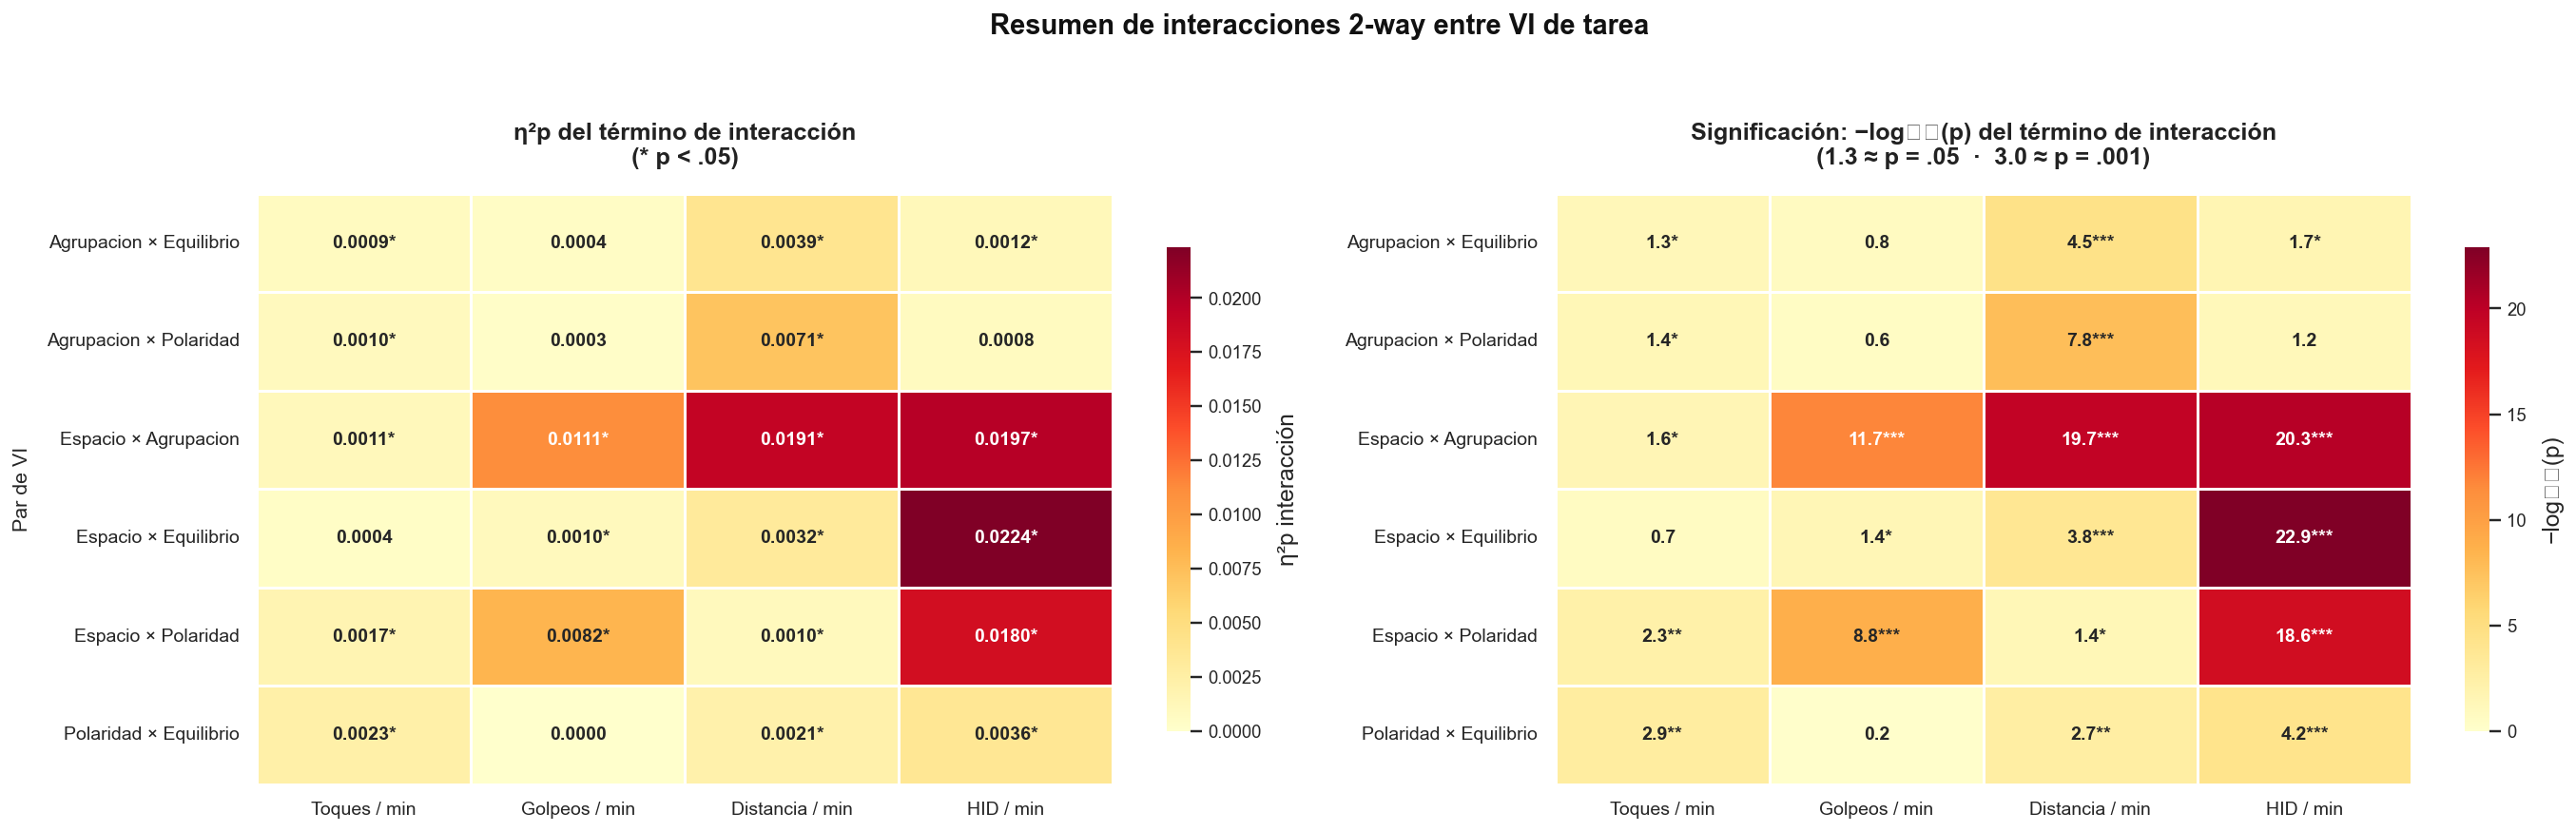

In [5]:
# ── Sección 4: Heatmaps resumen ──────────────────────────

# ── 4.1 Preparar pivots ──────────────────────────────────
pivot_eta = df_anova.pivot_table(
    index="Par VI", columns="VD", values="η²p interacción", aggfunc="first"
)[vd_labels]

pivot_p = df_anova.pivot_table(
    index="Par VI", columns="VD", values="p interacción", aggfunc="first"
)[vd_labels]

pivot_logp = -np.log10(pivot_p.clip(lower=1e-300))

# ── 4.2 Anotaciones con asteriscos ───────────────────────
annot_eta = pd.DataFrame("", index=pivot_eta.index, columns=pivot_eta.columns)
for par in pivot_eta.index:
    for vd_l in pivot_eta.columns:
        eta_val = pivot_eta.loc[par, vd_l]
        p_val = pivot_p.loc[par, vd_l]
        star = "*" if p_val < 0.05 else ""
        annot_eta.loc[par, vd_l] = f"{eta_val:.4f}{star}"

annot_logp = pd.DataFrame("", index=pivot_logp.index, columns=pivot_logp.columns)
for par in pivot_logp.index:
    for vd_l in pivot_logp.columns:
        logp_val = pivot_logp.loc[par, vd_l]
        p_val = pivot_p.loc[par, vd_l]
        star = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
        annot_logp.loc[par, vd_l] = f"{logp_val:.1f}{star}"

# ── 4.3 Dibujar heatmaps lado a lado ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Heatmap 1: η²p
sns.heatmap(
    pivot_eta.astype(float), annot=annot_eta, fmt="", cmap="YlOrRd",
    linewidths=1.5, linecolor="white", ax=ax1, vmin=0,
    cbar_kws={"label": "η²p interacción", "shrink": 0.82},
    annot_kws={"fontsize": 10, "fontweight": "bold"},
)
ax1.set_title(
    "η²p del término de interacción\n(* p < .05)",
    fontsize=13, fontweight="bold", color="#222", pad=16,
)
ax1.set_ylabel("Par de VI", fontsize=11)
ax1.set_xlabel("")
ax1.tick_params(labelsize=10)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Heatmap 2: -log10(p)
sns.heatmap(
    pivot_logp.astype(float), annot=annot_logp, fmt="", cmap="YlOrRd",
    linewidths=1.5, linecolor="white", ax=ax2, vmin=0,
    cbar_kws={"label": "−log₁₀(p)", "shrink": 0.82},
    annot_kws={"fontsize": 10, "fontweight": "bold"},
)
ax2.set_title(
    "Significación: −log₁₀(p) del término de interacción\n"
    "(1.3 ≈ p = .05  ·  3.0 ≈ p = .001)",
    fontsize=13, fontweight="bold", color="#222", pad=16,
)
ax2.set_ylabel("")
ax2.set_xlabel("")
ax2.tick_params(labelsize=10)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

# Líneas de referencia en heatmap de -log10(p)
# (Las líneas horizontales de referencia se señalan en el título)

fig.suptitle(
    "Resumen de interacciones 2-way entre VI de tarea",
    fontsize=15, fontweight="bold", color="#111", y=1.04,
)
fig.tight_layout()
plt.show()

---
## Sección 5 — Interacciones sobre la inflación de ceros (Golpeos y HID)

Para las **2 VD con inflación de ceros** (Golpeos/min y HID/min), por cada par de VI:

1. **Tabla 2×2 del % de ceros** en cada celda del cruce.
2. **Regresión logística** con `statsmodels` (`GLM` con familia Binomial): `cero ~ C(VI₁) * C(VI₂)`, para evaluar si el término de interacción es significativo sobre la probabilidad de registrar 0.
3. **Interaction plot** del % de ceros (mismo formato que la Sección 2, pero con eje Y = proporción de ceros).

Esto extiende el análisis **interruptor/modulador** al contexto de interacciones: ¿la probabilidad de registrar 0 golpeos o 0 HID depende de la **combinación** de dos VI, no solo de cada una por separado?

In [6]:
# ── 5.1  Tablas 2×2 de % de ceros ────────────────────────

for vd, label in zip(vd_zeros, vd_zeros_labels):
    display(Markdown(f"### VD: **{label}** — % de ceros por celda 2×2"))
    
    for vi1, vi2 in pares_vi:
        filas = []
        for niv1 in vi_niveles[vi1]:
            for niv2 in vi_niveles[vi2]:
                sub = df[(df[vi1] == niv1) & (df[vi2] == niv2)][vd].dropna()
                n_total = len(sub)
                n_ceros = int((sub == 0).sum())
                pct_ceros = round((sub == 0).mean() * 100, 1) if n_total > 0 else np.nan
                filas.append({
                    vi1: niv1,
                    vi2: niv2,
                    "N": n_total,
                    "N ceros": n_ceros,
                    "% ceros": pct_ceros,
                })
        tabla = pd.DataFrame(filas)
        # Pivot para presentar como tabla 2×2
        pivot = tabla.pivot_table(
            index=vi1, columns=vi2, values="% ceros", aggfunc="first"
        )
        display(Markdown(f"**{vi1} × {vi2}**"))
        display(pivot.style.format("{:.1f} %").set_caption(f"% de ceros — {label}"))
    print()

### VD: **Golpeos / min** — % de ceros por celda 2×2

**Espacio × Agrupacion**

Agrupacion,grande,pequeno
Espacio,,
amplio,21.2 %,21.2 %
reducido,38.4 %,36.9 %


**Espacio × Polaridad**

Polaridad,No_polarizado,Polarizado
Espacio,,
amplio,36.8 %,19.7 %
reducido,50.3 %,30.5 %


...

Polaridad,No_polarizado,Polarizado
Agrupacion,,
grande,41.3 %,21.4 %
pequeno,44.4 %,32.6 %


**Agrupacion × Equilibrio**

Equilibrio,Desequilibrio,Equilibrio
Agrupacion,,
grande,38.8 %,22.7 %
pequeno,41.6 %,32.4 %


**Polaridad × Equilibrio**

Equilibrio,Desequilibrio,Equilibrio
Polaridad,,
No_polarizado,45.3 %,39.2 %
Polarizado,34.7 %,25.2 %


In [7]:
# ── 5.2  Regresión logística: interacción sobre la probabilidad de cero ──

filas_logit = []

for vd, label in zip(vd_zeros, vd_zeros_labels):
    # Variable binaria: 1 si es cero, 0 si > 0
    df["_es_cero"] = (df[vd] == 0).astype(int)
    
    for vi1, vi2 in pares_vi:
        formula = f'_es_cero ~ C({vi1}) * C({vi2})'
        try:
            modelo_logit = smf.glm(
                formula, data=df,
                family=sm.families.Binomial()
            ).fit()
            
            # Buscar el p-valor del término de interacción
            inter_params = [p for p in modelo_logit.params.index if ":" in p]
            if inter_params:
                inter_name = inter_params[0]
                p_inter = modelo_logit.pvalues[inter_name]
                coef_inter = modelo_logit.params[inter_name]
                or_inter = np.exp(coef_inter)
            else:
                p_inter = np.nan
                coef_inter = np.nan
                or_inter = np.nan
            
            sig = "***" if p_inter < 0.001 else ("**" if p_inter < 0.01 else ("*" if p_inter < 0.05 else "ns"))
            
            filas_logit.append({
                "VD": label,
                "Par VI": f"{vi1} × {vi2}",
                "Coef. interacción (logit)": round(coef_inter, 4),
                "OR interacción": round(or_inter, 4),
                "p interacción": p_inter,
                "Sig.": sig,
            })
        except Exception as e:
            filas_logit.append({
                "VD": label,
                "Par VI": f"{vi1} × {vi2}",
                "Coef. interacción (logit)": np.nan,
                "OR interacción": np.nan,
                "p interacción": np.nan,
                "Sig.": f"Error: {e}",
            })

# Eliminar columna auxiliar
df.drop(columns=["_es_cero"], inplace=True, errors="ignore")

df_logit = pd.DataFrame(filas_logit)

# Display con formato
df_logit_display = df_logit.copy()
df_logit_display["p interacción"] = df_logit_display["p interacción"].apply(
    lambda p: fmt_p(p) if not np.isnan(p) else "—"
)

display(Markdown("### Regresión logística: interacción sobre la probabilidad de cero"))
display(
    df_logit_display.style
    .set_caption("GLM Binomial — término de interacción sobre P(VD = 0)")
    .map(_color_sig, subset=["Sig."])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

print("\nOR > 1 → la combinación de niveles aumenta la odds de registrar 0.")
print("OR < 1 → la combinación de niveles reduce la odds de registrar 0.")

### Regresión logística: interacción sobre la probabilidad de cero

,VD,Par VI,Coef. interacción (logit),OR interacción,p interacción,Sig.
0,Golpeos / min,Espacio × Agrupacion,-0.063700,0.938300,0.6878,ns
1,Golpeos / min,Espacio × Polaridad,0.026800,1.027200,0.8860,ns
2,Golpeos / min,Espacio × Equilibrio,0.140500,1.150800,0.4228,ns
3,Golpeos / min,Agrupacion × Polaridad,0.659700,1.934300,1.99e-05,***
4,Golpeos / min,Agrupacion × Equilibrio,0.419000,1.520500,0.0103,*
5,Golpeos / min,Polaridad × Equilibrio,-0.467900,0.626300,0.0076,**
6,HID / min,Espacio × Agrupacion,0.194200,1.214400,0.2481,ns
7,HID / min,Espacio × Polaridad,0.713700,2.041600,1.79e-04,***
8,HID / min,Espacio × Equilibrio,0.616200,1.851800,4.87e-04,***
9,HID / min,Agrupacion × Polaridad,0.444600,1.559800,0.0041,**



OR > 1 → la combinación de niveles aumenta la odds de registrar 0.
OR < 1 → la combinación de niveles reduce la odds de registrar 0.


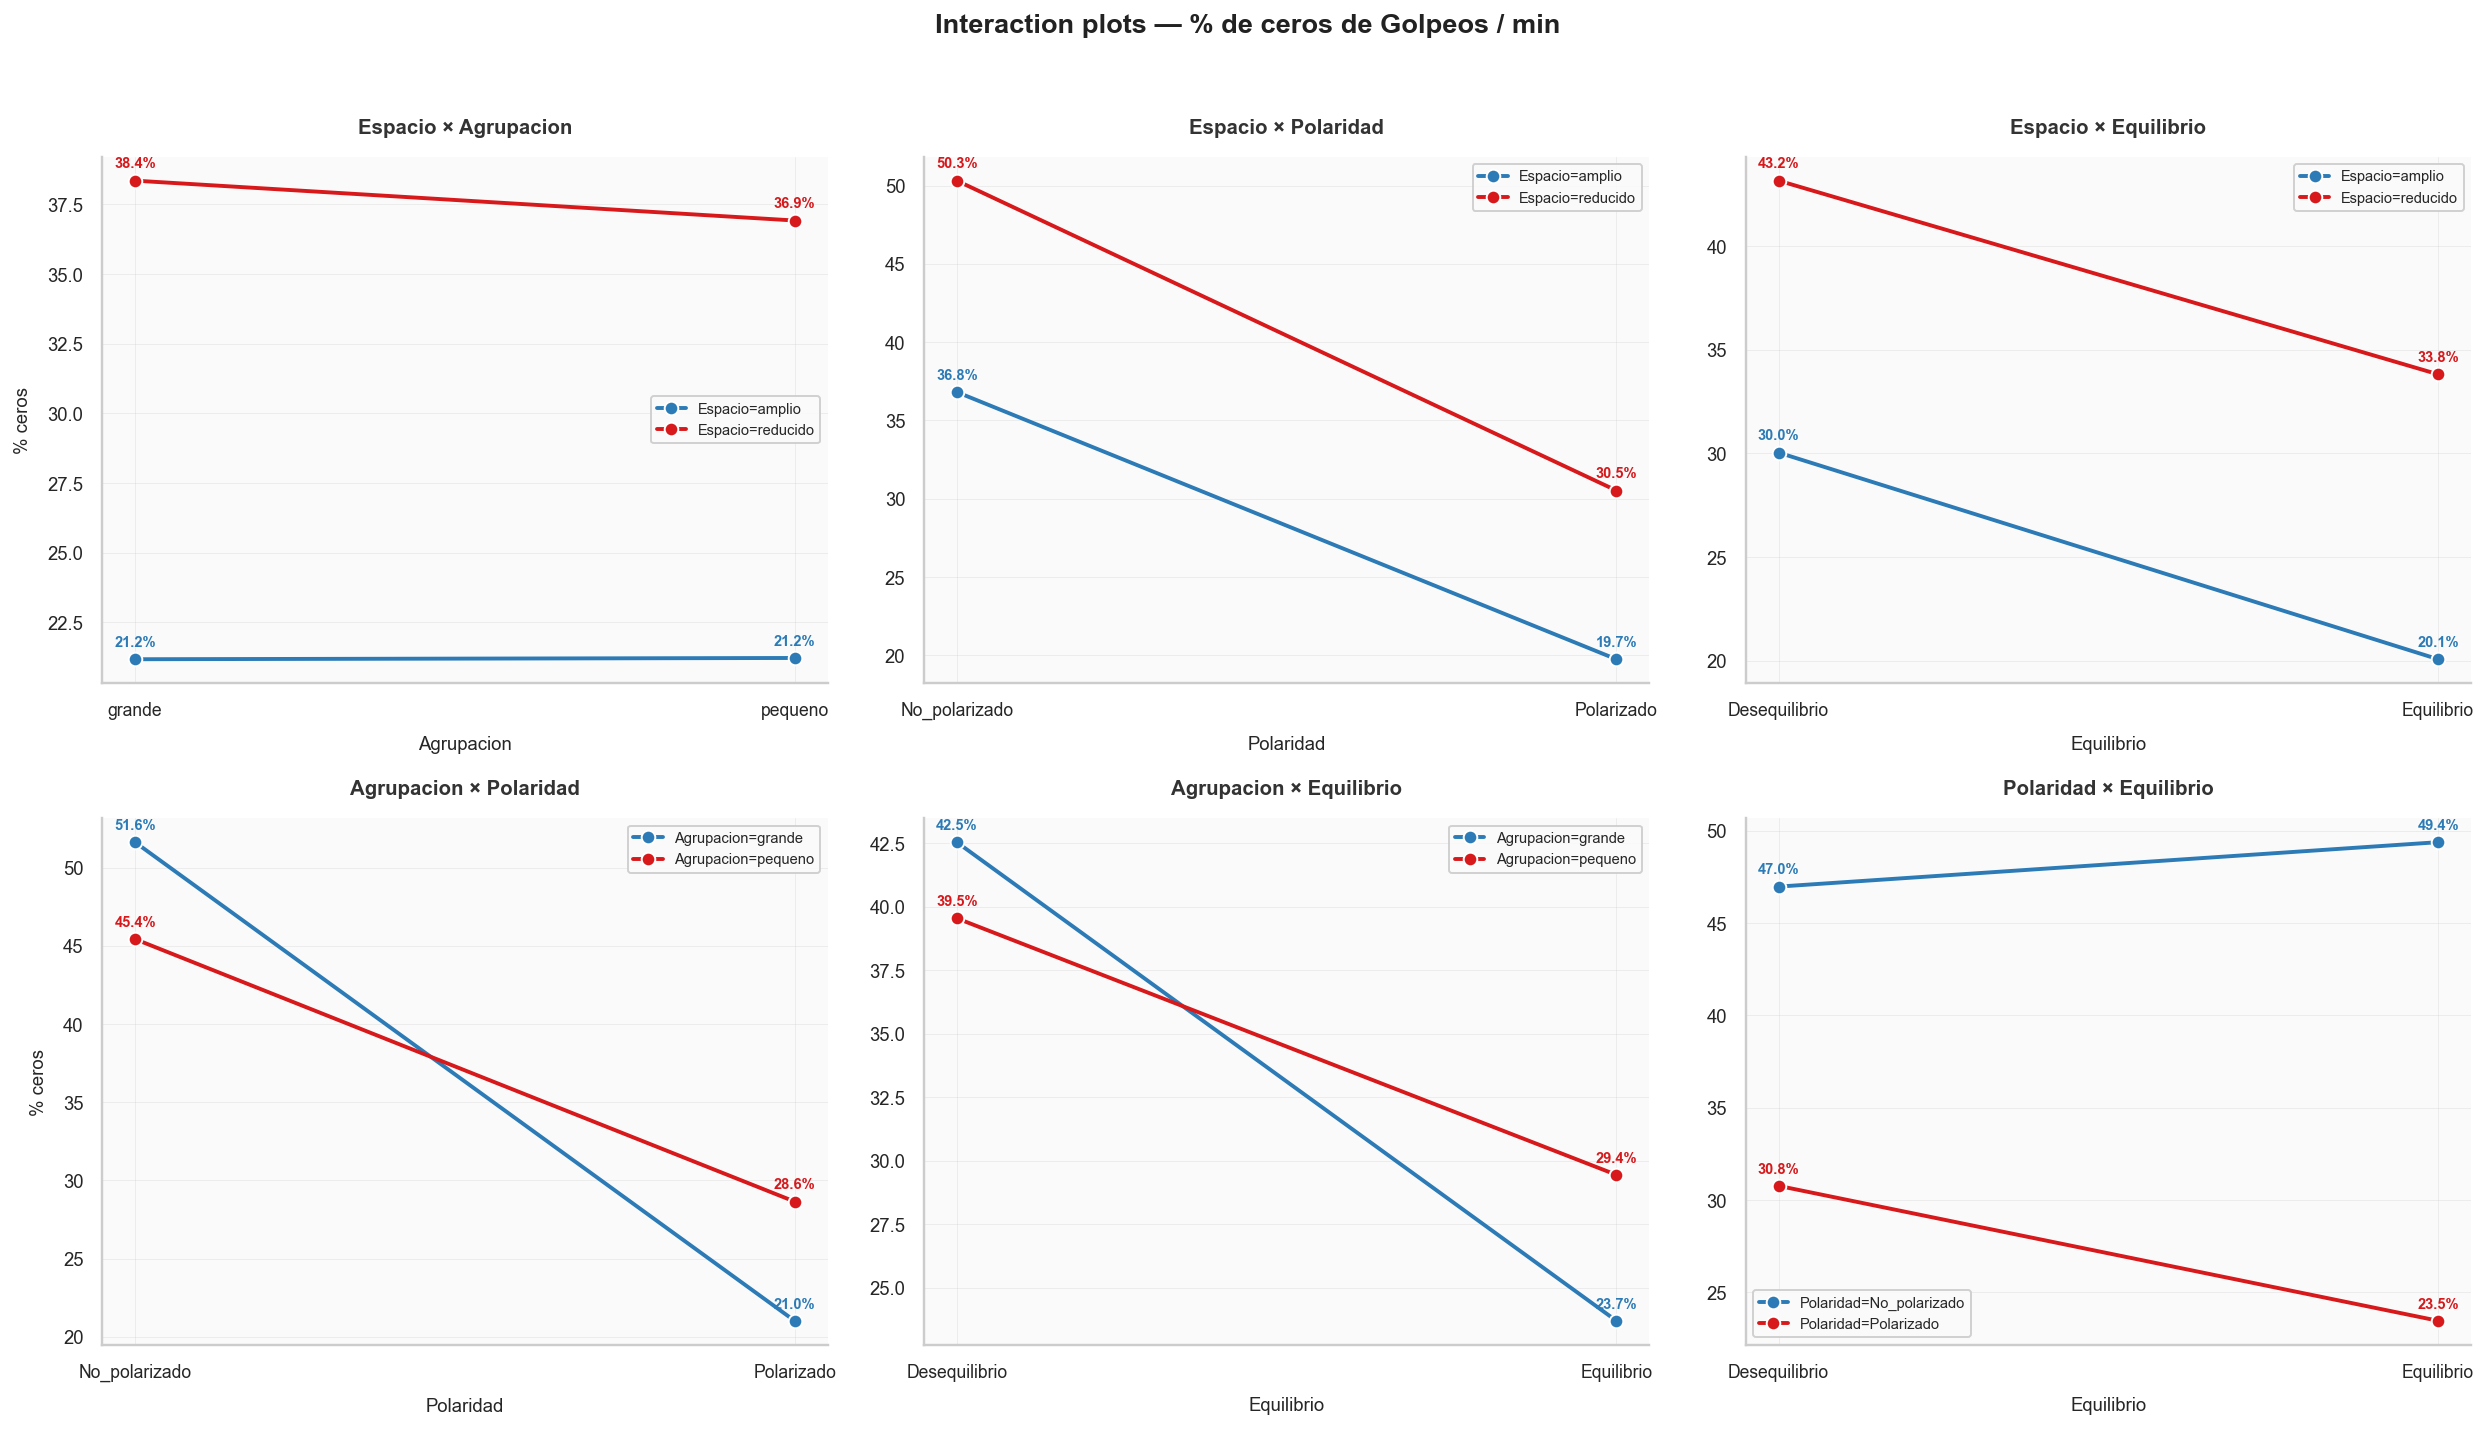

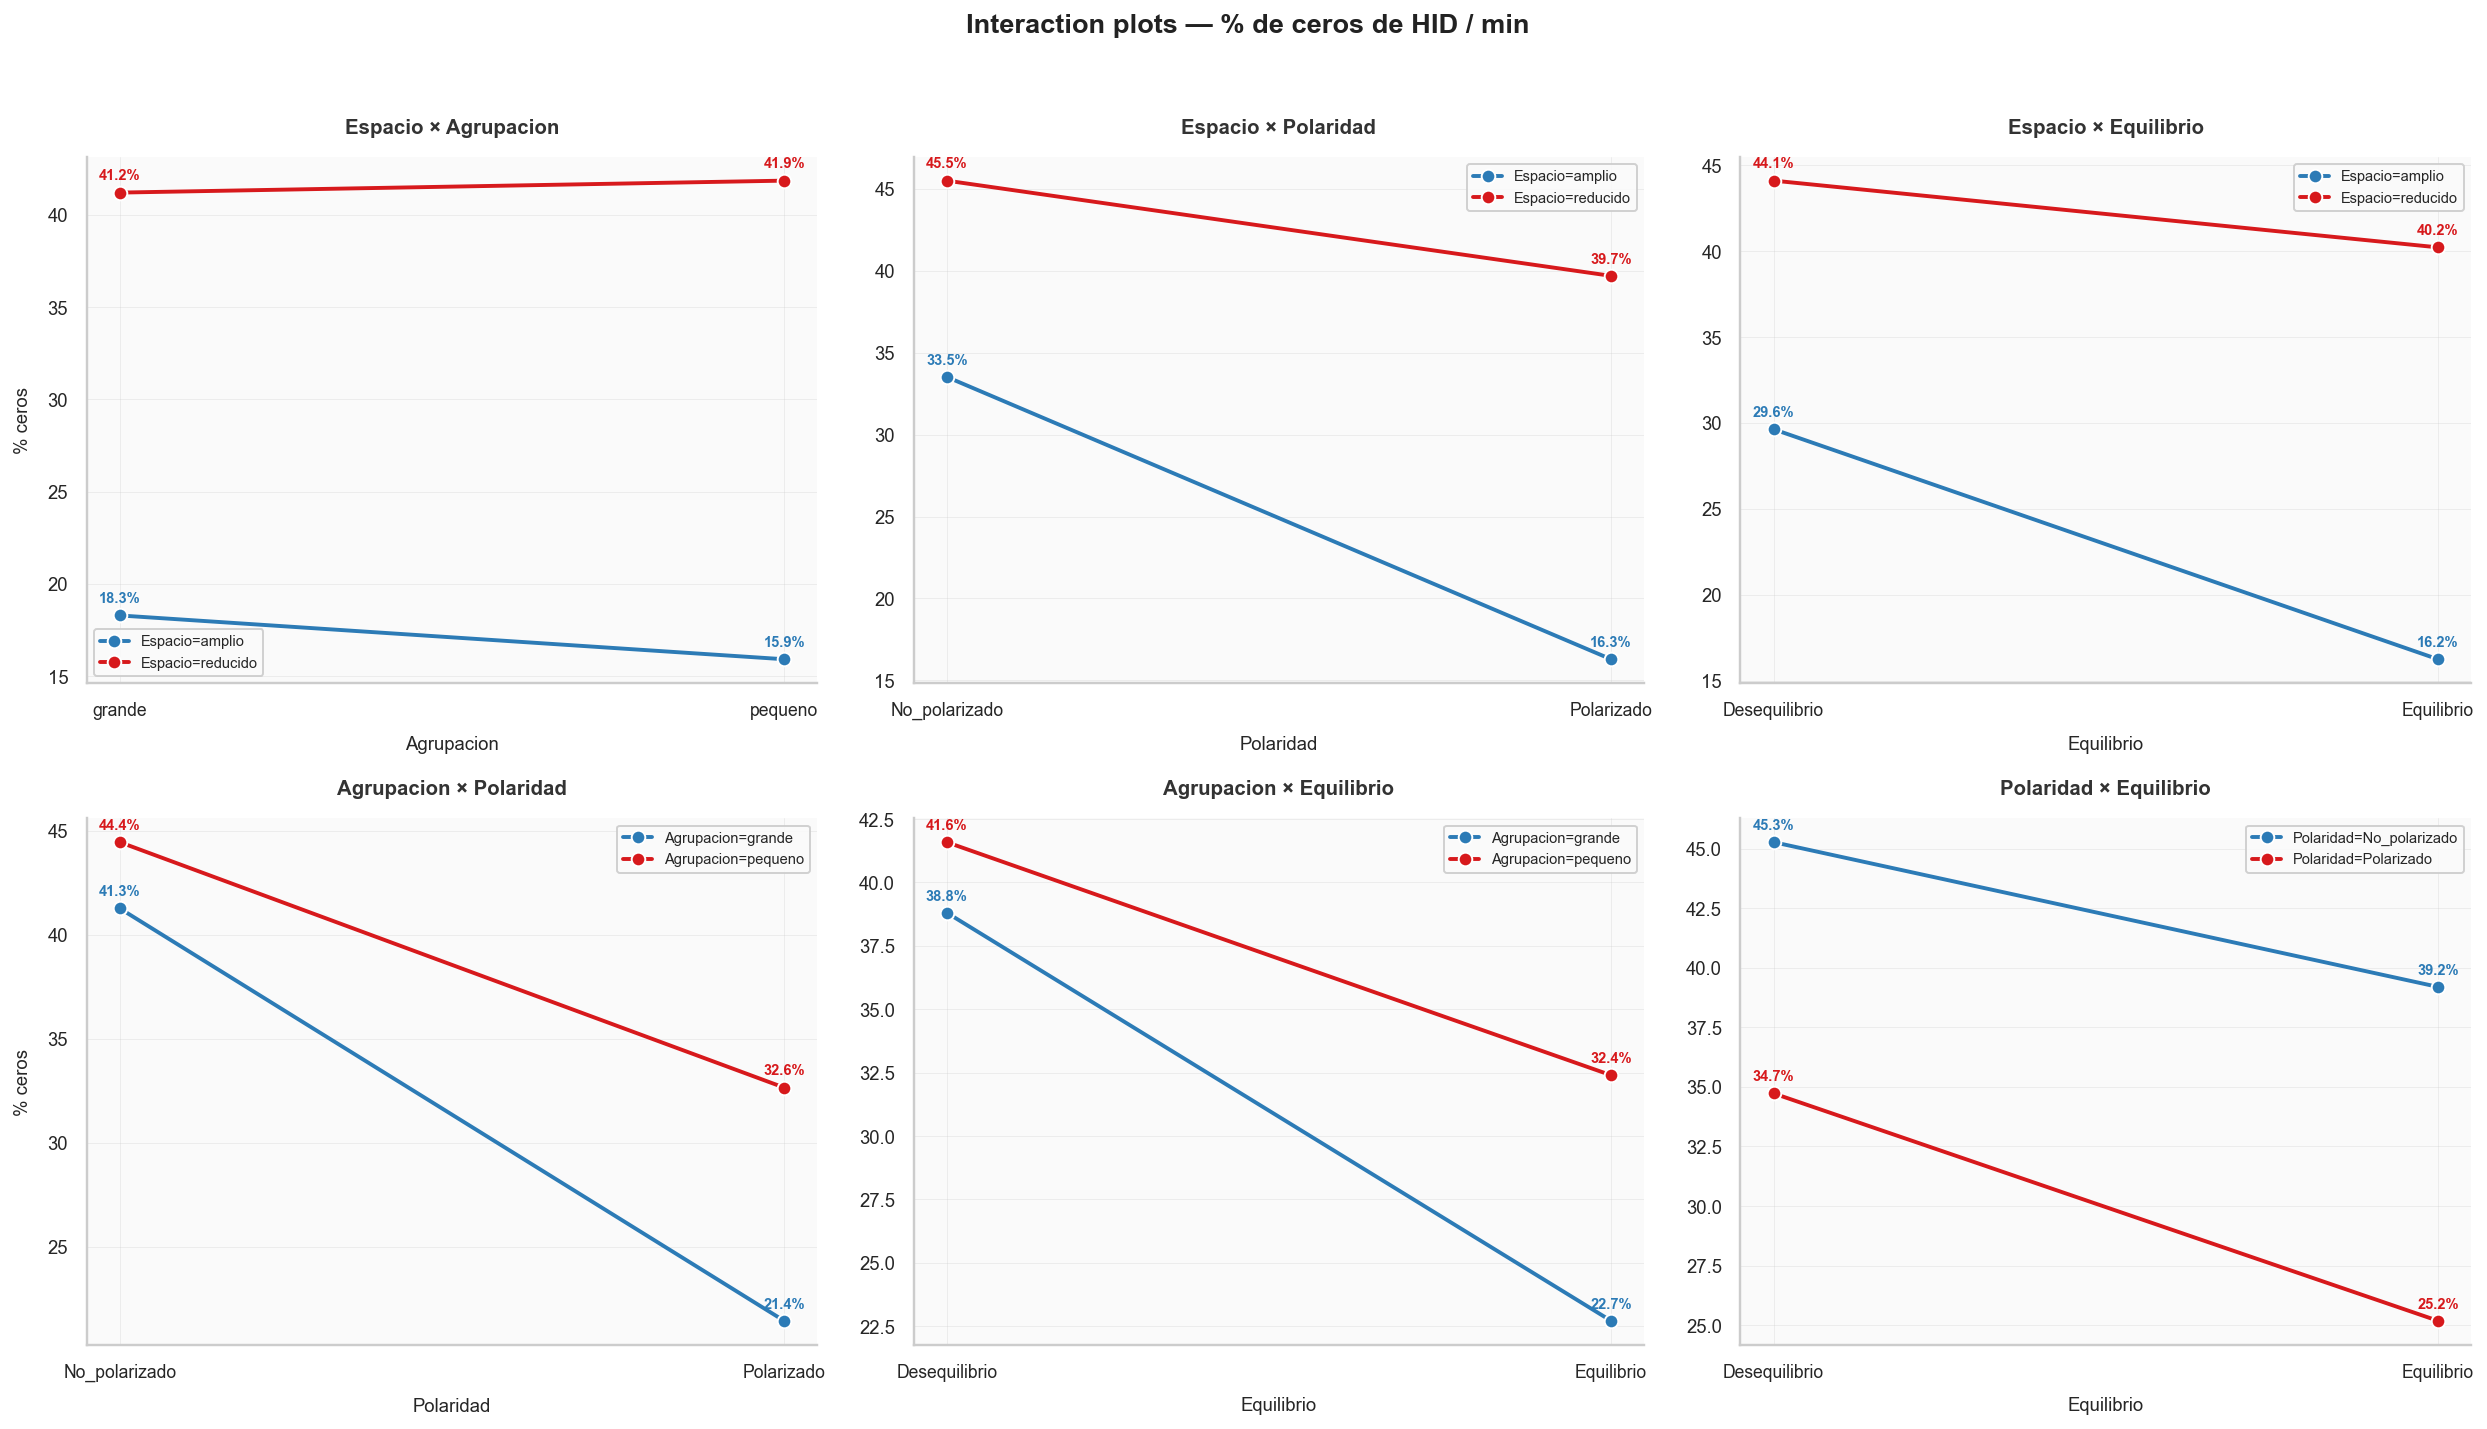

In [8]:
# ── 5.3  Interaction plots del % de ceros ────────────────

for vd, label in zip(vd_zeros, vd_zeros_labels):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    
    for idx_par, (vi1, vi2) in enumerate(pares_vi):
        ax = axes[idx_par]
        niveles_vi1 = vi_niveles[vi1]
        niveles_vi2 = vi_niveles[vi2]
        
        for k, niv1 in enumerate(niveles_vi1):
            pcts = []
            for niv2 in niveles_vi2:
                sub = df[(df[vi1] == niv1) & (df[vi2] == niv2)][vd].dropna()
                pct = (sub == 0).mean() * 100 if len(sub) > 0 else 0
                pcts.append(pct)
            
            ax.plot(
                range(len(niveles_vi2)), pcts,
                marker="o", markersize=7, linewidth=2.0,
                color=PAL_INTER[k], label=f"{vi1}={niv1}",
                markeredgecolor="white", markeredgewidth=1.0,
            )
            # Anotar valores
            for x_pos, pct_val in enumerate(pcts):
                ax.annotate(
                    f"{pct_val:.1f}%", xy=(x_pos, pct_val),
                    fontsize=7.5, ha="center", va="bottom",
                    xytext=(0, 5), textcoords="offset points",
                    fontweight="bold", color=PAL_INTER[k],
                )
        
        ax.set_xticks(range(len(niveles_vi2)))
        ax.set_xticklabels(niveles_vi2, fontsize=9)
        ax.set_xlabel(vi2, fontsize=9.5)
        ax.set_ylabel("% ceros" if idx_par % 3 == 0 else "", fontsize=9.5)
        ax.set_title(f"{vi1} × {vi2}", fontsize=10.5, fontweight="bold", color="#333")
        ax.legend(fontsize=7.5, loc="best", framealpha=0.9)
    
    fig.suptitle(
        f"Interaction plots — % de ceros de {label}",
        fontsize=14, fontweight="bold", color="#222", y=1.02,
    )
    fig.tight_layout()
    plt.show()

---
## Sección 6 — Tabla-resumen final y conclusiones

In [9]:
# ── 6.1  Tabla consolidada (24 combinaciones) ordenada por η²p ──

df_resumen_final = df_anova.copy()
df_resumen_final["Significativa"] = df_resumen_final["p interacción"].apply(
    lambda p: "Sí" if p < 0.05 else "No"
)
df_resumen_final["p interacción (fmt)"] = df_resumen_final["p interacción"].apply(fmt_p)
df_resumen_final["η²p interacción (fmt)"] = df_resumen_final["η²p interacción"].apply(
    lambda x: f"{x:.4f}"
)

# Ordenar por η²p descendente
df_resumen_final = df_resumen_final.sort_values("η²p interacción", ascending=False).reset_index(drop=True)

# Seleccionar columnas para display
cols_display = [
    "Par VI", "VD", "ΔΔ", "ΔΔ%", "η²p interacción (fmt)",
    "p interacción (fmt)", "Significativa", "Tamaño",
]

def _color_sig_sn(val):
    if val == "Sí":
        return "background-color: #F8D7DA; font-weight: bold"
    return ""

display(Markdown("### Tabla-resumen final — 24 interacciones ordenadas por η²p"))
display(
    df_resumen_final[cols_display].style
    .set_caption("Resumen de interacciones 2-way (6 pares × 4 VD), ordenadas por η²p descendente")
    .map(_color_tamano, subset=["Tamaño"])
    .map(_color_sig_sn, subset=["Significativa"])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

### Tabla-resumen final — 24 interacciones ordenadas por η²p

,Par VI,VD,ΔΔ,ΔΔ%,η²p interacción (fmt),p interacción (fmt),Significativa,Tamaño
0,Espacio × Equilibrio,HID / min,2.426700,130.660000,0.0224,1.25e-23,Sí,Pequeño
1,Espacio × Agrupacion,HID / min,1.947400,104.850000,0.0197,4.96e-21,Sí,Pequeño
2,Espacio × Agrupacion,Distancia / min,-16.848000,-21.280000,0.0191,2.23e-20,Sí,Pequeño
3,Espacio × Polaridad,HID / min,2.402900,129.370000,0.0180,2.72e-19,Sí,Pequeño
4,Espacio × Agrupacion,Golpeos / min,0.106800,65.350000,0.0111,1.89e-12,Sí,Pequeño
5,Espacio × Polaridad,Golpeos / min,-0.118400,-72.450000,0.0082,1.53e-09,Sí,Negligible
6,Agrupacion × Polaridad,Distancia / min,11.038200,13.940000,0.0071,1.77e-08,Sí,Negligible
7,Agrupacion × Equilibrio,Distancia / min,8.642600,10.920000,0.0039,3.00e-05,Sí,Negligible
8,Polaridad × Equilibrio,HID / min,-1.071500,-57.690000,0.0036,6.08e-05,Sí,Negligible
9,Espacio × Equilibrio,Distancia / min,8.352200,10.550000,0.0032,1.62e-04,Sí,Negligible


In [10]:
# ── 6.2  Ranking: Top interacciones más relevantes ───────

# Top 5 por η²p
display(Markdown("### Top 5 interacciones por η²p (mayor tamaño de efecto)"))
top_eta = df_resumen_final.head(5)[
    ["Par VI", "VD", "η²p interacción (fmt)", "ΔΔ", "ΔΔ%", "p interacción (fmt)", "Tamaño"]
]
display(top_eta)

# Top 5 por |ΔΔ%|
display(Markdown("### Top 5 interacciones por |ΔΔ%| (mayor impacto relativo)"))
top_dd = (
    df_resumen_final
    .assign(**{"abs_ΔΔ%": df_resumen_final["ΔΔ%"].abs()})
    .sort_values("abs_ΔΔ%", ascending=False)
    .head(5)[
        ["Par VI", "VD", "ΔΔ", "ΔΔ%", "η²p interacción (fmt)", "p interacción (fmt)", "Tamaño"]
    ]
)
display(top_dd)

### Top 5 interacciones por η²p (mayor tamaño de efecto)

,Par VI,VD,η²p interacción (fmt),ΔΔ,ΔΔ%,p interacción (fmt),Tamaño
0,Espacio × Equilibrio,HID / min,0.0224,2.4267,130.66,1.25e-23,Pequeño
1,Espacio × Agrupacion,HID / min,0.0197,1.9474,104.85,4.96e-21,Pequeño
2,Espacio × Agrupacion,Distancia / min,0.0191,-16.8480,-21.28,2.23e-20,Pequeño
3,Espacio × Polaridad,HID / min,0.0180,2.4029,129.37,2.72e-19,Pequeño
4,Espacio × Agrupacion,Golpeos / min,0.0111,0.1068,65.35,1.89e-12,Pequeño


### Top 5 interacciones por |ΔΔ%| (mayor impacto relativo)

,Par VI,VD,ΔΔ,ΔΔ%,η²p interacción (fmt),p interacción (fmt),Tamaño
0,Espacio × Equilibrio,HID / min,2.4267,130.66,0.0224,1.25e-23,Pequeño
3,Espacio × Polaridad,HID / min,2.4029,129.37,0.0180,2.72e-19,Pequeño
1,Espacio × Agrupacion,HID / min,1.9474,104.85,0.0197,4.96e-21,Pequeño
5,Espacio × Polaridad,Golpeos / min,-0.1184,-72.45,0.0082,1.53e-09,Negligible
4,Espacio × Agrupacion,Golpeos / min,0.1068,65.35,0.0111,1.89e-12,Pequeño


In [11]:
# ── 6.3  Resumen del análisis sobre ceros ────────────────

display(Markdown("### Resumen de interacciones sobre la inflación de ceros (Golpeos y HID)"))

# Combinar info de regresión logística con ANOVA
filas_resumen_ceros = []
for _, row in df_logit.iterrows():
    vd_label = row["VD"]
    par_vi = row["Par VI"]
    
    # Buscar η²p correspondiente del ANOVA sobre la VD continua
    match = df_anova[
        (df_anova["VD"] == vd_label) & (df_anova["Par VI"] == par_vi)
    ]
    eta2p_continua = match["η²p interacción"].values[0] if len(match) > 0 else np.nan
    p_continua = match["p interacción"].values[0] if len(match) > 0 else np.nan
    
    filas_resumen_ceros.append({
        "VD": vd_label,
        "Par VI": par_vi,
        "p interacción (ceros)": fmt_p(row["p interacción"]) if not np.isnan(row["p interacción"]) else "—",
        "OR interacción": round(row["OR interacción"], 3) if not np.isnan(row["OR interacción"]) else "—",
        "Sig. ceros": "Sí" if row["p interacción"] < 0.05 else "No",
        "p interacción (continua)": fmt_p(p_continua),
        "η²p (continua)": f"{eta2p_continua:.4f}",
        "Sig. continua": "Sí" if p_continua < 0.05 else "No",
        "Opera sobre": (
            "Ambas" if (row["p interacción"] < 0.05 and p_continua < 0.05) else
            "Ceros" if row["p interacción"] < 0.05 else
            "Continua" if p_continua < 0.05 else
            "Ninguna"
        ),
    })

df_resumen_ceros = pd.DataFrame(filas_resumen_ceros)

def _color_opera(val):
    mapa = {"Ambas": "#F8D7DA", "Ceros": "#FFF3CD", "Continua": "#D1ECF1", "Ninguna": "#D4EDDA"}
    return f"background-color: {mapa.get(val, '')}"

display(
    df_resumen_ceros.style
    .set_caption("Interacciones sobre la parte de ceros vs. la parte continua")
    .map(_color_opera, subset=["Opera sobre"])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

### Resumen de interacciones sobre la inflación de ceros (Golpeos y HID)

,VD,Par VI,p interacción (ceros),OR interacción,Sig. ceros,p interacción (continua),η²p (continua),Sig. continua,Opera sobre
0,Golpeos / min,Espacio × Agrupacion,0.6878,0.938000,No,1.89e-12,0.0111,Sí,Continua
1,Golpeos / min,Espacio × Polaridad,0.8860,1.027000,No,1.53e-09,0.0082,Sí,Continua
2,Golpeos / min,Espacio × Equilibrio,0.4228,1.151000,No,0.0360,0.0010,Sí,Continua
3,Golpeos / min,Agrupacion × Polaridad,1.99e-05,1.934000,Sí,0.2688,0.0003,No,Ceros
4,Golpeos / min,Agrupacion × Equilibrio,0.0103,1.520000,Sí,0.1617,0.0004,No,Ceros
5,Golpeos / min,Polaridad × Equilibrio,0.0076,0.626000,Sí,0.6717,0.0000,No,Ceros
6,HID / min,Espacio × Agrupacion,0.2481,1.214000,No,4.96e-21,0.0197,Sí,Continua
7,HID / min,Espacio × Polaridad,1.79e-04,2.042000,Sí,2.72e-19,0.0180,Sí,Ambas
8,HID / min,Espacio × Equilibrio,4.87e-04,1.852000,Sí,1.25e-23,0.0224,Sí,Ambas
9,HID / min,Agrupacion × Polaridad,0.0041,1.560000,Sí,0.0574,0.0008,No,Ceros


---
## Conclusiones

### 1. ¿Qué interacciones alcanzan significación estadística y tamaño de efecto al menos pequeño?

La tabla-resumen final (Sección 6.1) identifica las interacciones con p < .05 y η²p ≥ .01. Estas son las candidatas a incluir como términos de interacción explícitos en los GLMM. Las interacciones con η²p < .01, incluso si son significativas, deben considerarse con cautela dado el gran tamaño muestral (N = 4 446), que otorga potencia para detectar efectos triviales.

### 2. ¿Los efectos base de la Fase 3 son mayoritariamente aditivos o hay interacciones que los modifican sustancialmente?

La evidencia visual de los interaction plots (Sección 2) y los valores de ΔΔ% permiten evaluar si las líneas son aproximadamente paralelas (efectos aditivos) o si se cruzan/divergen (interacciones genuinas). Se debe examinar si las interacciones significativas presentan ΔΔ% > 10–15 %, lo cual indicaría una modificación sustancial del efecto base.

- El efecto base de Espacio sobre Toques/min fue *d* = −0.77 (Fase 3). Si su interacción con otra VI muestra η²p ≥ .01, el efecto no es puramente aditivo.
- El efecto base de Polaridad sobre Toques/min fue *d* = 0.90 (Fase 3). Las interacciones que lo modifiquen son especialmente relevantes dado su magnitud.

### 3. ¿Qué interacciones deberían incluirse como términos en los GLMM?

**Criterios de inclusión:**
- η²p ≥ .01 **y** p < .05 → Incluir como interacción fija.
- η²p < .01 pero p < .001 → Evaluar caso a caso; la significación puede deberse al N.
- η²p < .01 y p > .05 → No incluir.

### 4. Para Golpeos y HID: ¿las interacciones operan sobre la parte de ceros, sobre la parte continua, o sobre ambas?

La tabla 6.3 clasifica cada interacción según si alcanza significación en:
- La **parte de ceros** (regresión logística, Sección 5.2)
- La **parte continua** (ANOVA factorial, Sección 3)
- **Ambas partes**

Esta distinción es crítica para la especificación de los modelos hurdle/zero-inflated:
- Interacciones que operan sobre **ceros** → incluir en el componente logístico.
- Interacciones que operan sobre la parte **continua** → incluir en el componente Gamma/log-normal.
- Interacciones que operan sobre **ambas** → incluir en ambos componentes.

> **Nota final:** Los resultados de este análisis descriptivo bivariante de interacciones deben interpretarse con cautela, ya que no controlan por GrupoEdad ni por la estructura jerárquica de los datos (observaciones anidadas en jugadores). Los GLMM de fases posteriores proporcionarán estimaciones ajustadas de los términos de interacción.